In [22]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


import os
import tempfile

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.distributions.empirical_distribution import ECDF

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)


In [23]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:1b087523-b47b-421c-97c4-74da80564598,2018-09-25 18:17:26.647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.0,1.0,1.0,1.0,NaN,3.0,9.0,NaN,hr-rct-cue-1
1,us-east-1:ea986d8e-e87d-458b-a798-1999fbbff05b,2018-09-26 17:13:52.394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,NaN,4.0,21.0,NaN,hr-rct-cue-1
2,us-east-1:8dfca9b6-22b6-4155-8a70-ce3e1211a684,2018-09-27 19:04:15.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,1.0,NaN,6.0,22.0,NaN,hr-rct-cue-1
3,us-east-1:77f43bb4-fe8e-4a50-a4fc-41bc14b11f9d,2018-10-01 22:01:32.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,2.0,0.0,NaN,2.0,10.0,NaN,hr-rct-cue-1
4,us-east-1:4940dfa3-1c01-49f2-9cdd-029291d7b7a8,2018-10-05 21:08:52.441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,3.0,1.0,0.0,NaN,6.0,18.0,NaN,hr-rct-cue-1


In [24]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(6820, 158)
Count of rows: 6820
Count of columns: 158


In [25]:
df.deployment.value_counts()

deployment
hr-ascent-1      2924
hr-uchealth-1    1512
hr-internal-1    1031
hr-rct-ctrl-1     700
hr-rct-cue-1      653
Name: count, dtype: int64

In [148]:
df[['age_bucket',
 'age_num',
 'sex',
 'gender',
 'chronotype',
 'housemates',
 'occupation',
 'school',
 'phone_carry',
 'full_time',
 'ethnicity',
]].head()

,age_bucket,age_num,sex,gender,chronotype,housemates,occupation,school,phone_carry,full_time,ethnicity
0,45-54,51,Female,Woman,<NA>,"other relatives,unrelated housemate(s)",<NA>,<NA>,Always,<NA>,[Asian]
1,18-24,23,Female,Woman,<NA>,no one,<NA>,<NA>,Frequently,True,[Asian]
2,45-54,52,Female,Woman,<NA>,children,<NA>,<NA>,Always,<NA>,[White]
3,35-44,39,Female,Woman,<NA>,no one,<NA>,<NA>,Frequently,<NA>,"[Asian, White]"
4,25-34,33,Female,Woman,<NA>,spouse/partner,<NA>,<NA>,Always,<NA>,[Black_Or_African_American]


In [147]:
df.columns.tolist()

['user_id',
 'ts',
 'active_time_m7',
 'active_time_m14',
 'active_time_s7',
 'active_time_s14',
 'activity_percent_m7',
 'activity_percent_m14',
 'activity_percent_s7',
 'activity_percent_s14',
 'chronotype_score_m7',
 'chronotype_score_m14',
 'chronotype_score_s7',
 'chronotype_score_s14',
 'display_events_m7',
 'display_events_m14',
 'display_events_s7',
 'display_events_s14',
 'ec_Activity_m7',
 'ec_Activity_m14',
 'ec_Activity_s7',
 'ec_Activity_s14',
 'ec_DeviceDisplayStatus_m7',
 'ec_DeviceDisplayStatus_m14',
 'ec_DeviceDisplayStatus_s7',
 'ec_DeviceDisplayStatus_s14',
 'ec_Location_m7',
 'ec_Location_m14',
 'ec_Location_s7',
 'ec_Location_s14',
 'ec_PedometerData_m7',
 'ec_PedometerData_m14',
 'ec_PedometerData_s7',
 'ec_PedometerData_s14',
 'ec_total_m7',
 'ec_total_m14',
 'ec_total_s7',
 'ec_total_s14',
 'time_at_location_1_m7',
 'time_at_location_1_m14',
 'time_at_location_1_s7',
 'time_at_location_1_s14',
 'time_at_location_2_m7',
 'time_at_location_2_m14',
 'time_at_locati

In [26]:
df[df['phq8_total'].notnull()].groupby('deployment').size().reset_index(name='count')

,deployment,count
0,hr-ascent-1,2924
1,hr-internal-1,1031
2,hr-rct-ctrl-1,700
3,hr-rct-cue-1,653
4,hr-uchealth-1,1512


In [27]:
df.sex.value_counts()

sex
Female    4575
Male      1792
Other        9
Name: count, dtype: Int64

In [28]:
df.sex.isna()

444

In [29]:
def get_binary_age(age_bucket: str):
    if '85' in age_bucket:
        return 'old'
    ub = int(age_bucket.strip().split('-')[-1])
    if ub < 45:
        return 'young'
    return 'old'

df['age_binary'] = df.age_bucket.apply(lambda x: None if pd.isnull(x) else get_binary_age(x))
df.age_binary.value_counts()

age_binary
young    4024
old      2351
Name: count, dtype: int64

In [30]:
df.shape

(6820, 159)

In [31]:
4024+2351

6375

In [32]:
df.age_binary.isna().sum()

445

In [33]:
6375+445

6820

In [34]:
# For stakeholders: Filter the dataset to include only the 'hr-ascent-1' deployment
df = df[df.deployment == 'hr-ascent-1']
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment,age_binary
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1,old
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1,young
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1,old
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1,young
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1,young


In [35]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(2924, 159)
Count of rows: 2924
Count of columns: 159


In [36]:
df.sex.value_counts()

sex
Female    2314
Male       610
Name: count, dtype: Int64

In [37]:
df.sex.isna().sum()

0

In [38]:
2314+610

2924

In [39]:
def get_binary_age(age_bucket: str):
    if '85' in age_bucket:
        return 'old'
    ub = int(age_bucket.strip().split('-')[-1])
    if ub < 45:
        return 'young'
    return 'old'

df['age_binary'] = df.age_bucket.apply(lambda x: None if pd.isnull(x) else get_binary_age(x))
df.age_binary.value_counts()

age_binary
young    1671
old      1253
Name: count, dtype: int64

In [40]:
df.shape

(2924, 159)

In [41]:
df.age_binary.isna().sum()

0

In [42]:
1671+1253

2924

In [44]:
df.age_bucket.value_counts()

age_bucket
35-44    808
45-54    681
25-34    640
55-64    447
18-24    216
65-74    120
16-18      7
75-84      5
Name: count, dtype: Int64

In [45]:
808+681+640+447+216+120+7+5

2924

In [50]:
df.shape

(2924, 159)

In [61]:
df.isna().sum().sort_values(ascending=False).head(30)

school                     2924
occupation                 2924
chronotype                 2924
sleep_end_m14              2411
sleep_end_s14              2411
sleep_start_s14            2411
sleep_duration_s14         2411
sleep_start_m14            2411
sleep_duration_m14         2411
sleep_interruptions_s14    2411
sleep_interruptions_m14    2411
full_time                  2138
sleep_end_m7               2133
sleep_end_s7               2133
sleep_start_m7             2133
sleep_interruptions_m7     2133
sleep_interruptions_s7     2133
sleep_start_s7             2133
sleep_duration_s7          2133
sleep_duration_m7          2133
travel_diameter_m14        1494
travel_diameter_s14        1494
time_at_location_5_s14     1428
time_at_location_5_m14     1428
time_at_location_4_m14     1322
time_at_location_4_s14     1322
travel_diameter_m7         1300
travel_diameter_s7         1300
walking_rate_m14           1291
walking_rate_s14           1291
dtype: int64

In [59]:
df.user_id.nunique()

601

In [62]:
df.groupby('deployment').sleep_duration_m7.apply(lambda x: x.isnull().mean())

deployment
hr-ascent-1    0.72948
Name: sleep_duration_m7, dtype: float64

In [ ]:
# Identify sensor-related columns (excluding fully missing/complete columns)
sensor_cols = [col for col in df.columns if 0 < df[col].isna().sum() < len(df)]

# Flag days with any missing sensor data
df['any_missing'] = df[sensor_cols].isnull().any(axis=1)

# Calculate missing proportion per user
missing_per_user = df.groupby('user_id')['any_missing'].agg(['sum', 'count'])
missing_per_user['missing_proportion'] = missing_per_user['sum'] / missing_per_user['count']

# Display distribution
print("Missing days distribution per user:")
print(missing_per_user['missing_proportion'].describe())

# Plot histogram
missing_per_user['missing_proportion'].hist(title='Proportion of Missing Days per User')

In [63]:
# Identify sensor-related columns (excluding fully missing/complete columns)
sensor_cols = [col for col in df.columns if 0 < df[col].isna().sum() < len(df)]
sensor_cols

['active_time_m7',
 'active_time_m14',
 'active_time_s7',
 'active_time_s14',
 'activity_percent_m7',
 'activity_percent_m14',
 'activity_percent_s7',
 'activity_percent_s14',
 'chronotype_score_m7',
 'chronotype_score_m14',
 'chronotype_score_s7',
 'chronotype_score_s14',
 'display_events_m7',
 'display_events_m14',
 'display_events_s7',
 'display_events_s14',
 'ec_Activity_m7',
 'ec_Activity_m14',
 'ec_Activity_s7',
 'ec_Activity_s14',
 'ec_DeviceDisplayStatus_m7',
 'ec_DeviceDisplayStatus_m14',
 'ec_DeviceDisplayStatus_s7',
 'ec_DeviceDisplayStatus_s14',
 'ec_Location_m7',
 'ec_Location_m14',
 'ec_Location_s7',
 'ec_Location_s14',
 'ec_PedometerData_m7',
 'ec_PedometerData_m14',
 'ec_PedometerData_s7',
 'ec_PedometerData_s14',
 'ec_total_m7',
 'ec_total_m14',
 'ec_total_s7',
 'ec_total_s14',
 'time_at_location_1_m7',
 'time_at_location_1_m14',
 'time_at_location_1_s7',
 'time_at_location_1_s14',
 'time_at_location_2_m7',
 'time_at_location_2_m14',
 'time_at_location_2_s7',
 'time_at

In [91]:

# Flag days with any missing sensor data
df['any_missing'] = df[sensor_cols].isnull().any(axis=1)
df[['user_id', 'ts', 'active_time_s14', 'ec_Activity_s14', 'display_events_s14', 'any_missing']].head()

,user_id,ts,active_time_s14,ec_Activity_s14,display_events_s14,any_missing
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,True
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,True
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,True
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,True
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,True


In [92]:
df['any_missing'].value_counts()

any_missing
True     2840
False      84
Name: count, dtype: int64

In [93]:

# Calculate missing proportion per user
missing_per_user = df.groupby('user_id')['any_missing'].agg(['sum', 'count']).reset_index()
missing_per_user

,user_id,sum,count
0,us-east-1:db841a21-c400-c09b-cb33-144516a80231,6,6
1,us-east-1:db841a21-c400-ce85-5cd6-95d896fd3268,6,6
2,us-east-1:db841a21-c402-c83f-fadf-41f6d4271053,2,2
3,us-east-1:db841a21-c402-c9e0-501c-45fd38e3b5e3,1,1
4,us-east-1:db841a21-c402-cf75-e0bb-eec187eb84b1,4,4
...,...,...,...
596,us-east-1:db841a21-c4ff-c644-6a64-0583e73a79d9,5,5
597,us-east-1:db841a21-c4ff-c868-02a6-5cfff64a075a,6,6
598,us-east-1:db841a21-c4ff-cb45-cad0-4821d631eb58,6,6
599,us-east-1:db841a21-c4ff-cb63-a6da-f45b3c81a5c5,6,6


In [118]:
missing_per_user['missing_proportion'] = missing_per_user['sum'] / missing_per_user['count']
missing_per_user = missing_per_user[['user_id', 'count', 'sum', 'missing_proportion']]

In [120]:
missing_per_user[missing_per_user.missing_proportion < 0.7].sort_values(by='missing_proportion', ascending=False)

,user_id,count,sum,missing_proportion
37,us-east-1:db841a21-c40e-c22d-b761-8771da86141a,6,4,0.666667
357,us-east-1:db841a21-c494-cf20-c1f5-ddec795b01a3,6,4,0.666667
102,us-east-1:db841a21-c42e-c314-d622-ec5f1dba1aea,6,4,0.666667
144,us-east-1:db841a21-c43a-c301-6e75-a36024ae9141,6,4,0.666667
228,us-east-1:db841a21-c45e-c357-9a9f-48aa3c798e93,6,4,0.666667
506,us-east-1:db841a21-c4d5-c35d-43f5-c26ccae7b0fc,6,4,0.666667
381,us-east-1:db841a21-c49e-c931-7b51-57fde617ab2a,6,4,0.666667
587,us-east-1:db841a21-c4fd-c71d-1765-8c87c9420706,7,4,0.571429
206,us-east-1:db841a21-c456-c39a-2aaf-dd7212a0de33,7,4,0.571429
566,us-east-1:db841a21-c4f3-c8d6-94a2-2cb75f040ade,7,4,0.571429


In [121]:
missing_per_user['missing_proportion'].describe()


count    601.000000
mean       0.974249
std        0.102657
min        0.333333
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: missing_proportion, dtype: float64

<Axes: >

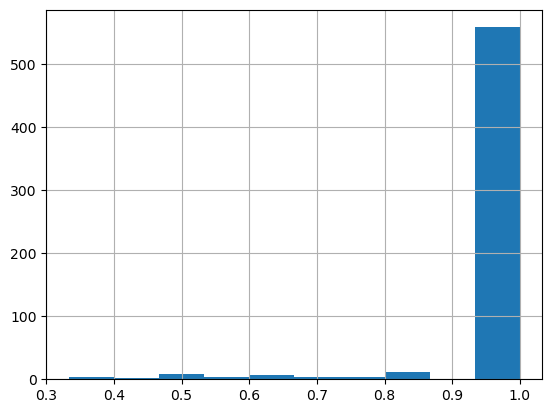

In [122]:
# Plot histogram
missing_per_user['missing_proportion'].hist()

# 2. Identify Users Who Did Not Generate Data
    Goal: Find users with all sensor data missing (indicating inactive users).

In [124]:
# Check if all sensor columns are fully missing for a user
all_sensor_missing = df.groupby('user_id')[sensor_cols].apply(lambda x: x.isnull().all().all())
inactive_users = all_sensor_missing[all_sensor_missing].index.tolist()

print(f"Users with no sensor data: {inactive_users}")

Users with no sensor data: []


In [132]:
df.groupby('user_id')['step_count_m7'].apply(lambda x: x.isnull().all().all())

user_id
us-east-1:db841a21-c400-c09b-cb33-144516a80231    False
us-east-1:db841a21-c400-ce85-5cd6-95d896fd3268     True
us-east-1:db841a21-c402-c83f-fadf-41f6d4271053    False
us-east-1:db841a21-c402-c9e0-501c-45fd38e3b5e3     True
us-east-1:db841a21-c402-cf75-e0bb-eec187eb84b1    False
                                                  ...  
us-east-1:db841a21-c4ff-c644-6a64-0583e73a79d9    False
us-east-1:db841a21-c4ff-c868-02a6-5cfff64a075a    False
us-east-1:db841a21-c4ff-cb45-cad0-4821d631eb58    False
us-east-1:db841a21-c4ff-cb63-a6da-f45b3c81a5c5    False
us-east-1:db841a21-c4ff-cf28-acdc-a8ab36af1fa3    False
Name: step_count_m7, Length: 601, dtype: bool

In [142]:
# Set threshold (e.g., 20% missing days)
threshold = 0.35
active_users = missing_per_user[missing_per_user['missing_proportion'] <= threshold].index.tolist()

print(f"Active users (≤{threshold*100}% missing days): {len(active_users)}")

Active users (≤35.0% missing days): 4


In [145]:
# Overall null percentage per user
total_null_cells = df.groupby('user_id')[sensor_cols].apply(lambda x: x.isnull().sum().sum())
total_possible_cells = df.groupby('user_id').size() * len(sensor_cols)
null_percentage = (total_null_cells / total_possible_cells) * 100

#print("Overall null percentage per user:")
null_percentage.sort_values()

user_id
us-east-1:db841a21-c4a8-cc44-b0a3-7957a2f8e753     2.205882
us-east-1:db841a21-c406-ccf9-7dce-71496e2b0b9c     4.411765
us-east-1:db841a21-c469-c9bb-f4c0-35adfc14e767     9.558824
us-east-1:db841a21-c453-cdbf-70fc-6f564b5574dc    11.764706
us-east-1:db841a21-c4fc-cde7-6a1b-898e6a76f951    12.500000
                                                    ...    
us-east-1:db841a21-c439-c1e0-45f3-7db03e1ecaaf    97.794118
us-east-1:db841a21-c447-cf7a-85f4-c42a7cffab11    97.794118
us-east-1:db841a21-c419-c9e1-016a-6025f1cccae2    97.794118
us-east-1:db841a21-c427-cd89-5089-19b6f437097b    97.794118
us-east-1:db841a21-c496-c52d-d7c1-dfd1ae2164bd    97.794118
Length: 601, dtype: float64

In [146]:

# Per-column null percentage (for detailed analysis)
user_null_per_column = df.groupby('user_id')[sensor_cols].apply(lambda x: x.isnull().mean() * 100)
#print("\nDetailed per-column null percentages:")
user_null_per_column

,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,chronotype_score_m7,chronotype_score_m14,...,walking_rate_s7,walking_rate_s14,device_use_percent_m7,device_use_percent_m14,device_use_percent_s7,device_use_percent_s14,full_time,ethnicity,phq_q2,phq_q6
user_id,,,,,,,,,,,,,,,,,,,,,
us-east-1:db841a21-c400-c09b-cb33-144516a80231,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,33.333333,...,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,100.0,0.0,0.0,0.0
us-east-1:db841a21-c400-ce85-5cd6-95d896fd3268,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,33.333333,33.333333,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,0.0,0.0,0.0
us-east-1:db841a21-c402-c83f-fadf-41f6d4271053,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,100.0,0.0,0.0,0.0
us-east-1:db841a21-c402-c9e0-501c-45fd38e3b5e3,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.0,0.0,0.0,0.0
us-east-1:db841a21-c402-cf75-e0bb-eec187eb84b1,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,25.000000,25.000000,...,50.000000,50.000000,50.000000,100.000000,50.000000,100.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
us-east-1:db841a21-c4ff-c644-6a64-0583e73a79d9,60.000000,80.000000,60.000000,80.000000,60.000000,80.000000,60.000000,80.000000,40.000000,80.000000,...,60.000000,80.000000,60.000000,80.000000,60.000000,80.000000,100.0,0.0,0.0,0.0
us-east-1:db841a21-c4ff-c868-02a6-5cfff64a075a,33.333333,33.333333,33.333333,33.333333,33.333333,33.333333,33.333333,33.333333,33.333333,50.000000,...,33.333333,33.333333,50.000000,50.000000,50.000000,50.000000,100.0,0.0,0.0,0.0
us-east-1:db841a21-c4ff-cb45-cad0-4821d631eb58,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,33.333333,...,16.666667,16.666667,16.666667,16.666667,16.666667,16.666667,100.0,0.0,0.0,0.0


In [8]:
df[df['phq8_total'].notnull()].groupby('deployment').size().reset_index(name='count')

,deployment,count
0,hr-ascent-1,2924


In [ ]:
df['step_count_m7'].describe()

In [ ]:
sns.histplot(df['step_count_m7'].dropna(),  kde=True, color='skyblue')
plt.title("Distribution of step_count_m7")
plt.xlabel('step_count_m7 (m7)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
def analyze(inf: str, target: str):
    df_clean = df.dropna(subset=[inf, target])
    model = smf.ols(formula=f'{target} ~ {inf}', data=df_clean).fit()
    return model.summary()

display(analyze('step_count_m7', 'phq_q8'))

In [ ]:
def get_binary_age(age_bucket: str):
    if '85' in age_bucket:
        return 'old'
    ub = int(age_bucket.strip().split('-')[-1])
    if ub < 45:
        return 'young'
    return 'old'

df['age_binary'] = df.age_bucket.apply(lambda x: None if pd.isnull(x) else get_binary_age(x))

def analyze(inf: str, target: str, df: pd.DataFrame):
    df_clean = df.dropna(subset=[inf, target, 'sex', 'age_binary'])
    df_clean = df_clean[df_clean.sex != 'Other']
    
    df_clean['sex'] = df_clean.sex.astype(str)
    df_clean['age_binary'] = df_clean.age_binary.astype(str)
    
    model = smf.ols(formula=f'{target} ~ {inf} : C(sex) : C(age_binary)', data=df_clean).fit()
    return model.summary()


print(analyze('step_count_m7', 'phq_q8', df))

## Perform Scaling and Categorical Encoding.

In [ ]:
df_clean = df.dropna(subset=['step_count_m7', 'sex', 'age_binary', 'phq_q8'])
df_clean=df_clean[['step_count_m7', 'sex', 'age_binary', 'phq_q8']]
df_clean

### Standard Scaling

In [ ]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
numeric_cols.tolist()

In [ ]:
scaler=StandardScaler(with_mean=False, with_std=True)
scaler.fit(df_clean[['step_count_m7']])

df_clean[['step_count_m7_scaled']]= scaler.transform(df_clean[['step_count_m7']])
df_clean

In [ ]:
df_clean.columns

In [ ]:
df_clean = df_clean[['step_count_m7', 'step_count_m7_scaled', 'sex', 'age_binary', 'phq_q8', ]]
df_clean

In [ ]:
sns.histplot(df_clean['step_count_m7'].dropna(),  kde=True, color='skyblue')
plt.title("Distribution of step_count_m7 without Scaling")
plt.xlabel('step_count_m7 (m7)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
sns.histplot(df_clean['step_count_m7_scaled'].dropna(),  kde=True, color='skyblue')
plt.title("Distribution of step_count_m7 with Scaling")
plt.xlabel('step_count_m7 (m7)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
df_clean.describe()

### Categorical Encodings using OneHotEncoder or Label Encoders

In [ ]:
# df_clean.head()

In [ ]:
# categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns
# print("Categorical columns:", categorical_cols)

In [ ]:
# df_clean[categorical_cols]

In [ ]:
# df_one_hot_enc = pd.get_dummies(df_clean, columns=categorical_cols)
# df_one_hot_enc

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le_sex = LabelEncoder()
# le_age = LabelEncoder()

# # Perform label encoding on each column
# df_clean['sex_encoded'] = le_sex.fit_transform(df_clean['sex'])
# df_clean['age_binary_encoded'] = le_age.fit_transform(df_clean['age_binary'])

# df_clean.head()

# Final OLS regression begins here.

In [1]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


import os
import tempfile

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.distributions.empirical_distribution import ECDF

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:1b087523-b47b-421c-97c4-74da80564598,2018-09-25 18:17:26.647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.0,1.0,1.0,1.0,NaN,3.0,9.0,NaN,hr-rct-cue-1
1,us-east-1:ea986d8e-e87d-458b-a798-1999fbbff05b,2018-09-26 17:13:52.394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,NaN,4.0,21.0,NaN,hr-rct-cue-1
2,us-east-1:8dfca9b6-22b6-4155-8a70-ce3e1211a684,2018-09-27 19:04:15.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,1.0,NaN,6.0,22.0,NaN,hr-rct-cue-1
3,us-east-1:77f43bb4-fe8e-4a50-a4fc-41bc14b11f9d,2018-10-01 22:01:32.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,2.0,0.0,NaN,2.0,10.0,NaN,hr-rct-cue-1
4,us-east-1:4940dfa3-1c01-49f2-9cdd-029291d7b7a8,2018-10-05 21:08:52.441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,3.0,1.0,0.0,NaN,6.0,18.0,NaN,hr-rct-cue-1


In [3]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(6820, 158)
Count of rows: 6820
Count of columns: 158


In [4]:
# For stakeholders: Filter the dataset to include only the 'hr-ascent-1' deployment
df = df[df.deployment == 'hr-ascent-1']
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [5]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(2924, 158)
Count of rows: 2924
Count of columns: 158


In [6]:
def get_binary_age(age_bucket: str):
    if '85' in age_bucket:
        return 'old'
    ub = int(age_bucket.strip().split('-')[-1])
    if ub < 45:
        return 'young'
    return 'old'

df['age_binary'] = df.age_bucket.apply(lambda x: None if pd.isnull(x) else get_binary_age(x))

def analyze(inf: str, target: str, df: pd.DataFrame):
    
    df_clean = df.dropna(subset=[inf, target, 'sex', 'age_binary'])
    
    df_clean = df_clean[df_clean.sex != 'Other']
    
    df_clean['sex'] = df_clean.sex.astype(str)
    df_clean['age_binary'] = df_clean.age_binary.astype(str)
    
    model = smf.ols(formula=f'{target} ~ {inf} : C(sex) : C(age_binary)', data=df_clean).fit()
    
    return model.summary()

In [7]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(2924, 159)
Count of rows: 2924
Count of columns: 159


In [8]:
columns = df.columns.tolist()
columns


['user_id',
 'ts',
 'active_time_m7',
 'active_time_m14',
 'active_time_s7',
 'active_time_s14',
 'activity_percent_m7',
 'activity_percent_m14',
 'activity_percent_s7',
 'activity_percent_s14',
 'chronotype_score_m7',
 'chronotype_score_m14',
 'chronotype_score_s7',
 'chronotype_score_s14',
 'display_events_m7',
 'display_events_m14',
 'display_events_s7',
 'display_events_s14',
 'ec_Activity_m7',
 'ec_Activity_m14',
 'ec_Activity_s7',
 'ec_Activity_s14',
 'ec_DeviceDisplayStatus_m7',
 'ec_DeviceDisplayStatus_m14',
 'ec_DeviceDisplayStatus_s7',
 'ec_DeviceDisplayStatus_s14',
 'ec_Location_m7',
 'ec_Location_m14',
 'ec_Location_s7',
 'ec_Location_s14',
 'ec_PedometerData_m7',
 'ec_PedometerData_m14',
 'ec_PedometerData_s7',
 'ec_PedometerData_s14',
 'ec_total_m7',
 'ec_total_m14',
 'ec_total_s7',
 'ec_total_s14',
 'time_at_location_1_m7',
 'time_at_location_1_m14',
 'time_at_location_1_s7',
 'time_at_location_1_s14',
 'time_at_location_2_m7',
 'time_at_location_2_m14',
 'time_at_locati

In [9]:
df_columns_required = ['user_id', 'phq8_total','sex', 'age_bucket','age_binary']
df_columns_required

['user_id', 'phq8_total', 'sex', 'age_bucket', 'age_binary']

## 1. Activity Bucket OLS Results

In [88]:
active_columns  =[col for col in columns if 'activ' in col]
active_columns

['active_time_m7',
 'active_time_m14',
 'active_time_s7',
 'active_time_s14',
 'activity_percent_m7',
 'activity_percent_m14',
 'activity_percent_s7',
 'activity_percent_s14',
 'steps_least_active_5h_m7',
 'steps_least_active_5h_m14',
 'steps_least_active_5h_s7',
 'steps_least_active_5h_s14',
 'steps_most_active_10h_m7',
 'steps_most_active_10h_m14',
 'steps_most_active_10h_s7',
 'steps_most_active_10h_s14',
 'total_activity_duration_m7',
 'total_activity_duration_m14',
 'total_activity_duration_s7',
 'total_activity_duration_s14']

In [ ]:
df[active_columns]

In [ ]:
scaler=StandardScaler(with_mean=False, with_std=True)
scaler.fit(df[active_columns])

df[active_columns]= scaler.transform(df[active_columns])

In [ ]:
df[active_columns]

In [87]:
total_columns =  df_columns_required + active_columns
total_columns

['user_id',
 'phq8_total',
 'sex',
 'age_bucket',
 'age_binary',
 'ec_Activity_m7',
 'ec_Activity_m14',
 'ec_Activity_s7',
 'ec_Activity_s14']

In [ ]:
# Create a base output directory in the current working directory
output_dir = os.path.join(os.getcwd(), "active_infrences_outputs")
os.makedirs(output_dir, exist_ok=True)
target = 'phq8_total'

def analyze_all_sleep_data():
    for col in active_columns:
        m = analyze(col, target, df)
        log_dir = os.path.join(output_dir, "ols")
        os.makedirs(log_dir, exist_ok=True)
        log_file = os.path.join(log_dir, f'{col}.txt')
        with open(log_file, 'w') as f:
            f.write(str(m))
        print(f"Logged results for {col} in category {col} to {log_file}.")

analyze_all_sleep_data()

In [ ]:
active_columns  = [col for col in columns if 'activ' in col]

scaler=StandardScaler(with_mean=False, with_std=True)
scaler.fit(df[active_columns])
df[active_columns]= scaler.transform(df[active_columns])

total_columns =  df_columns_required + active_columns


# Create a base output directory in the current working directory
output_dir = os.path.join(os.getcwd(), "active_infrences_outputs")
os.makedirs(output_dir, exist_ok=True)
target = 'phq8_total'

def analyze_all_sleep_data():
    for col in active_columns:
        m = analyze(col, target, df)
        log_dir = os.path.join(output_dir, "ols")
        os.makedirs(log_dir, exist_ok=True)
        log_file = os.path.join(log_dir, f'{col}.txt')
        with open(log_file, 'w') as f:
            f.write(str(m))
        print(f"Logged results for {col} in category {col} to {log_file}.")

analyze_all_sleep_data()

Logged results for active_time_m7 in category active_time_m7 to c:\Users\programming.com\Downloads\HR_Project\ver1\HR_ML_model_building\active_infrences_outputs\ols\active_time_m7.txt.
Logged results for active_time_m14 in category active_time_m14 to c:\Users\programming.com\Downloads\HR_Project\ver1\HR_ML_model_building\active_infrences_outputs\ols\active_time_m14.txt.
Logged results for active_time_s7 in category active_time_s7 to c:\Users\programming.com\Downloads\HR_Project\ver1\HR_ML_model_building\active_infrences_outputs\ols\active_time_s7.txt.
Logged results for active_time_s14 in category active_time_s14 to c:\Users\programming.com\Downloads\HR_Project\ver1\HR_ML_model_building\active_infrences_outputs\ols\active_time_s14.txt.
Logged results for activity_percent_m7 in category activity_percent_m7 to c:\Users\programming.com\Downloads\HR_Project\ver1\HR_ML_model_building\active_infrences_outputs\ols\activity_percent_m7.txt.
Logged results for activity_percent_m14 in category ac

In [17]:
active_columns  = [col for col in columns if ('activ') and ('Activ') in col]
active_columns

['ec_Activity_m7', 'ec_Activity_m14', 'ec_Activity_s7', 'ec_Activity_s14']

In [11]:
sleep_columns  = [col for col in columns if 'sleep' in col]
sleep_columns

['sleep_duration_m7',
 'sleep_duration_m14',
 'sleep_duration_s7',
 'sleep_duration_s14',
 'sleep_end_m7',
 'sleep_end_m14',
 'sleep_end_s7',
 'sleep_end_s14',
 'sleep_interruptions_m7',
 'sleep_interruptions_m14',
 'sleep_interruptions_s7',
 'sleep_interruptions_s14',
 'sleep_start_m7',
 'sleep_start_m14',
 'sleep_start_s7',
 'sleep_start_s14',
 'sleep_routine_index_m7',
 'sleep_routine_index_m14',
 'sleep_routine_index_s7',
 'sleep_routine_index_s14']

## 2. Location Bucket OLS Results

In [18]:

# Define bucket keywords.
bucket_keywords = {
    
    "metadata": ["user_id", "ts"],
    
    "phq": ["phq_q", "phq2_total", "phq8_total", "phq9_total", "phq_category"],
    
    "demographics": [
        "age_bucket", "age_num", "age_binary", "sex", "gender", "chronotype",
        "housemates", "occupation", "school", "phone_carry", "full_time",
        "ethnicity", "deployment", "ethnicity_white"
    ],
    
    "sleep": ["sleep_", "chronotype_score"],
    "activity": [
        "active_time", "activity_percent", "ec_Activity", "ec_PedometerData",
        "steps_least_active", "steps_most_active", "steps_relative_amplitude",
        "step_count", "total_activity_duration", "walking_rate"
    ],
    
    "location": [
        "ec_Location", "time_at_location", "num_location_clusters", "loc_entropy",
        "total_location_duration", "travel_diameter", "time_at_home"
    ],
    
    "device": [
        "display_events", "screen_unlocks", "total_display_duration",
        "device_use_percent", "ec_DeviceDisplayStatus"
    ],
    
    "aggregated": ["ec_total"]
}

bucket_keywords

{'metadata': ['user_id', 'ts'],
 'phq': ['phq_q', 'phq2_total', 'phq8_total', 'phq9_total', 'phq_category'],
 'demographics': ['age_bucket',
  'age_num',
  'age_binary',
  'sex',
  'gender',
  'chronotype',
  'housemates',
  'occupation',
  'school',
  'phone_carry',
  'full_time',
  'ethnicity',
  'deployment',
  'ethnicity_white'],
 'sleep': ['sleep_', 'chronotype_score'],
 'activity': ['active_time',
  'activity_percent',
  'ec_Activity',
  'ec_PedometerData',
  'steps_least_active',
  'steps_most_active',
  'steps_relative_amplitude',
  'step_count',
  'total_activity_duration',
  'walking_rate'],
 'location': ['ec_Location',
  'time_at_location',
  'num_location_clusters',
  'loc_entropy',
  'total_location_duration',
  'travel_diameter',
  'time_at_home'],
 'device': ['display_events',
  'screen_unlocks',
  'total_display_duration',
  'device_use_percent',
  'ec_DeviceDisplayStatus'],
 'aggregated': ['ec_total']}

In [19]:

# Initialize buckets with empty lists
categorized_features = {bucket: [] for bucket in bucket_keywords}
categorized_features["other"] = []  # For features that don't match any bucket
categorized_features

{'metadata': [],
 'phq': [],
 'demographics': [],
 'sleep': [],
 'activity': [],
 'location': [],
 'device': [],
 'aggregated': [],
 'other': []}

In [ ]:
# Loop over each column and check which bucket keywords it contains.
for col in columns:
    assigned = False
    for bucket in ["metadata", "phq", "demographics", "sleep", "activity", "location", "device", "aggregated"]:
        for keyword in bucket_keywords[bucket]:
            if keyword in col:
                categorized_features[bucket].append(col)
                assigned = True
                break  # Stop at the first match for this bucket.
        if assigned:
            break
    if not assigned:
        categorized_features["other"].append(col)

# Print the categorized features
for bucket, feats in categorized_features.items():
    print(f"{bucket}:")
    for f in feats:
        print(f"  - {f}")
    print()  # Blank line for better readability

metadata:
  - user_id
  - ts
  - display_events_m7
  - display_events_m14
  - display_events_s7
  - display_events_s14

phq:
  - phq_q1
  - phq_q2
  - phq_q3
  - phq_q4
  - phq_q5
  - phq_q6
  - phq_q7
  - phq_q8
  - phq_q9
  - phq2_total
  - phq8_total
  - phq9_total

demographics:
  - chronotype_score_m7
  - chronotype_score_m14
  - chronotype_score_s7
  - chronotype_score_s14
  - age_bucket
  - age_num
  - sex
  - gender
  - chronotype
  - housemates
  - occupation
  - school
  - phone_carry
  - full_time
  - ethnicity
  - deployment
  - age_binary

sleep:
  - sleep_duration_m7
  - sleep_duration_m14
  - sleep_duration_s7
  - sleep_duration_s14
  - sleep_end_m7
  - sleep_end_m14
  - sleep_end_s7
  - sleep_end_s14
  - sleep_interruptions_m7
  - sleep_interruptions_m14
  - sleep_interruptions_s7
  - sleep_interruptions_s14
  - sleep_start_m7
  - sleep_start_m14
  - sleep_start_s7
  - sleep_start_s14
  - sleep_routine_index_m7
  - sleep_routine_index_m14
  - sleep_routine_index_s7
  - 

In [22]:
df_columns_required 

['user_id', 'phq8_total', 'sex', 'age_bucket', 'age_binary']

In [28]:
df.chronotype.isna().sum()

2924

In [23]:

# Define the bucket keywords to automatically categorize columns
bucket_keywords = {
    "metadata": ["user_id", "ts"],
    "phq": ["phq_q", "phq2_total", "phq8_total", "phq9_total", "phq_category"],
    "demographics": [
        "age_bucket", "age_num", "age_binary", "sex", "gender", "chronotype",
        "housemates", "occupation", "school", "phone_carry", "full_time",
        "ethnicity", "deployment", "ethnicity_white"
    ],
    "sleep": ["sleep_", "chronotype_score"],
    "activity": [
        "active_time", "activity_percent", "ec_Activity", "ec_PedometerData",
        "steps_least_active", "steps_most_active", "steps_relative_amplitude",
        "step_count", "total_activity_duration", "walking_rate"
    ],
    "location": [
        "ec_Location", "time_at_location", "num_location_clusters", "loc_entropy",
        "total_location_duration", "travel_diameter", "time_at_home"
    ],
    "device": [
        "display_events", "screen_unlocks", "total_display_duration",
        "device_use_percent", "ec_DeviceDisplayStatus"
    ],
    "aggregated": ["ec_total"]
}

# Automatically categorize the features
categorized_features = {bucket: [] for bucket in bucket_keywords}
categorized_features["other"] = []  # For features not matching any bucket

for col in columns:
    assigned = False
    # Check each bucket in order
    for bucket in ["metadata", "phq", "demographics", "sleep", "activity", "location", "device", "aggregated"]:
        for keyword in bucket_keywords[bucket]:
            if keyword in col:
                categorized_features[bucket].append(col)
                assigned = True
                break
        if assigned:
            break
    if not assigned:
        categorized_features["other"].append(col)
categorized_features

{'metadata': ['user_id',
  'ts',
  'display_events_m7',
  'display_events_m14',
  'display_events_s7',
  'display_events_s14'],
 'phq': ['phq_q1',
  'phq_q2',
  'phq_q3',
  'phq_q4',
  'phq_q5',
  'phq_q6',
  'phq_q7',
  'phq_q8',
  'phq_q9',
  'phq2_total',
  'phq8_total',
  'phq9_total'],
 'demographics': ['chronotype_score_m7',
  'chronotype_score_m14',
  'chronotype_score_s7',
  'chronotype_score_s14',
  'age_bucket',
  'age_num',
  'sex',
  'gender',
  'chronotype',
  'housemates',
  'occupation',
  'school',
  'phone_carry',
  'full_time',
  'ethnicity',
  'deployment',
  'age_binary'],
 'sleep': ['sleep_duration_m7',
  'sleep_duration_m14',
  'sleep_duration_s7',
  'sleep_duration_s14',
  'sleep_end_m7',
  'sleep_end_m14',
  'sleep_end_s7',
  'sleep_end_s14',
  'sleep_interruptions_m7',
  'sleep_interruptions_m14',
  'sleep_interruptions_s7',
  'sleep_interruptions_s14',
  'sleep_start_m7',
  'sleep_start_m14',
  'sleep_start_s7',
  'sleep_start_s14',
  'sleep_routine_index_m7',

In [24]:

# Set up required columns to include in every analysis run
df_columns_required = ['user_id', 'phq8_total', 'sex', 'age_bucket', 'age_binary']

# Create a base output directory in the current working directory for logs
output_dir = os.path.join(os.getcwd(), "OLS_results_inferences_outputs")
os.makedirs(output_dir, exist_ok=True)

target = 'phq8_total'

# Create a StandardScaler instance to scale numeric columns in each bucket.
scaler = StandardScaler(with_mean=False, with_std=True)

def analyze_all_bucket_data(df):
    # Loop through each bucket and its corresponding columns
    for bucket, bucket_cols in categorized_features.items():
        if not bucket_cols:
            continue  # Skip buckets with no features
        
        # Create a log directory for the current bucket
        bucket_log_dir = os.path.join(output_dir, bucket)
        os.makedirs(bucket_log_dir, exist_ok=True)
        
        # Determine which of these columns exist in the DataFrame (and assume numeric)
        cols_to_scale = [col for col in bucket_cols if col in df.columns]
        if cols_to_scale:
            scaler.fit(df[cols_to_scale])
            df[cols_to_scale] = scaler.transform(df[cols_to_scale])
        
        # Loop through each column in the bucket for analysis
        for col in bucket_cols:
            if col not in df.columns:
                continue  # Skip if column does not exist in the dataframe
            
            # Combine required columns with the current inference column
            total_cols = df_columns_required + [col]
            # Run your analysis (assumes function analyze(column, target, dataframe) exists)
            m = analyze(col, target, df[total_cols])
            
            # Write the analysis result into the corresponding bucket folder
            log_file = os.path.join(bucket_log_dir, f'{col}.txt')
            with open(log_file, 'w') as f:
                f.write(str(m))
            print(f"Logged results for {col} in bucket '{bucket}' to {log_file}.")

# Assuming df is your DataFrame and analyze() is defined, run the analysis:
analyze_all_bucket_data(df)


ValueError: could not convert string to float: 'us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e'

In [29]:
columns = df.columns
columns

Index(['user_id', 'ts', 'active_time_m7', 'active_time_m14', 'active_time_s7',
       'active_time_s14', 'activity_percent_m7', 'activity_percent_m14',
       'activity_percent_s7', 'activity_percent_s14',
       ...
       'phq_q5', 'phq_q6', 'phq_q7', 'phq_q8', 'phq_q9', 'phq2_total',
       'phq8_total', 'phq9_total', 'deployment', 'age_binary'],
      dtype='object', length=159)

In [30]:

# Define bucket conditions using lambda functions.
# Adjust these conditions as needed based on your naming conventions.
bucket_conditions = {
    'sleep': lambda col: ('sleep' in col) or ('chronotype' in col),
    'activity': lambda col: ('activ' in col) or ('step' in col) or ('walk' in col),
    'sociability': lambda col: ('location' in col) or ('loc_' in col) or ('home' in col) or ('travel' in col),
    'display': lambda col: ('display' in col) or ('screen_unlock' in col) or ('device' in col),
    'ec': lambda col: col.startswith('ec_')
}
bucket_conditions

{'sleep': <function __main__.<lambda>(col)>,
 'activity': <function __main__.<lambda>(col)>,
 'sociability': <function __main__.<lambda>(col)>,
 'display': <function __main__.<lambda>(col)>,
 'ec': <function __main__.<lambda>(col)>}

In [31]:

# Initialize buckets dictionary (including an 'others' bucket)
buckets = {bucket: [] for bucket in bucket_conditions}
buckets['others'] = []
buckets

{'sleep': [],
 'activity': [],
 'sociability': [],
 'display': [],
 'ec': [],
 'others': []}

In [32]:

# Categorize each column into the appropriate bucket
for col in columns:
    assigned = False
    for bucket, condition in bucket_conditions.items():
        if condition(col):
            buckets[bucket].append(col)
            assigned = True
            break
    if not assigned:
        buckets['others'].append(col)
buckets

{'sleep': ['chronotype_score_m7',
  'chronotype_score_m14',
  'chronotype_score_s7',
  'chronotype_score_s14',
  'sleep_duration_m7',
  'sleep_duration_m14',
  'sleep_duration_s7',
  'sleep_duration_s14',
  'sleep_end_m7',
  'sleep_end_m14',
  'sleep_end_s7',
  'sleep_end_s14',
  'sleep_interruptions_m7',
  'sleep_interruptions_m14',
  'sleep_interruptions_s7',
  'sleep_interruptions_s14',
  'sleep_start_m7',
  'sleep_start_m14',
  'sleep_start_s7',
  'sleep_start_s14',
  'sleep_routine_index_m7',
  'sleep_routine_index_m14',
  'sleep_routine_index_s7',
  'sleep_routine_index_s14',
  'chronotype'],
 'activity': ['active_time_m7',
  'active_time_m14',
  'active_time_s7',
  'active_time_s14',
  'activity_percent_m7',
  'activity_percent_m14',
  'activity_percent_s7',
  'activity_percent_s14',
  'steps_least_active_5h_m7',
  'steps_least_active_5h_m14',
  'steps_least_active_5h_s7',
  'steps_least_active_5h_s14',
  'steps_most_active_10h_m7',
  'steps_most_active_10h_m14',
  'steps_most_a

In [ ]:

# (Optional) Print the bucket mapping for verification
print("Buckets mapping:")
for bucket, cols in buckets.items():
    print(f"{bucket}: {cols}")

# Define columns you want to exclude from scaling (identifiers, targets, demographics, etc.)
exclude_cols = [
    'user_id', 'ts', 'sex', 'gender', 'age_bucket', 'age_num',
    'deployment', 'phq_q1', 'phq_q2', 'phq_q3', 'phq_q4',
    'phq_q5', 'phq_q6', 'phq_q7', 'phq_q8', 'phq_q9',
    'phq2_total', 'phq8_total', 'phq9_total', 'phq_category', 'age_binary'
]

# Initialize a StandardScaler instance (adjust with_mean/with_std as needed)
scaler = StandardScaler(with_mean=False, with_std=True)

# Loop through each bucket to scale numeric inference columns (if any)
for bucket, cols in buckets.items():
    # Only scale columns that are in the DataFrame and not in the exclude list
    cols_to_scale = [col for col in cols if col not in exclude_cols and col in df.columns]
    if cols_to_scale:
        scaler.fit(df[cols_to_scale])
        df[cols_to_scale] = scaler.transform(df[cols_to_scale])

# Define required columns that you always want to include (for example, identifiers/demographics)
df_columns_required = ['user_id', 'phq8_total', 'sex', 'age_bucket', 'age_binary']

# Create a base output directory for logs
base_output_dir = os.path.join(os.getcwd(), "inferences_outputs")
os.makedirs(base_output_dir, exist_ok=True)

# Define the target variable for analysis
target = 'phq8_total'

# Loop through each bucket, run analysis for each column, and log the output
for bucket, cols in buckets.items():
    # Create a folder for this bucket's outputs
    bucket_output_dir = os.path.join(base_output_dir, f"{bucket}_inferences_outputs")
    os.makedirs(bucket_output_dir, exist_ok=True)
    
    for col in cols:
        # Optionally skip columns that are part of df_columns_required
        if col in df_columns_required:
            continue
        # Run your analysis function
        m = analyze(col, target, df)
        # Define a log file name for this column
        log_file = os.path.join(bucket_output_dir, f'{col}.txt')
        # Write the results to the file
        with open(log_file, 'w') as f:
            f.write(str(m))
        print(f"Logged results for '{col}' in bucket '{bucket}' to {log_file}.")


In [34]:


# Define bucket rules: bucket name mapped to a list of identifying keywords (order matters if a column can match multiple buckets)
bucket_rules = {
    "demographics": [
        "user_id", "ts", "age_bucket", "age_num", "age_binary",
        "sex", "gender", "occupation", "school", "housemates",
        "ethnicity", "ethnicity_white", "deployment", "full_time",
        "phone_carry", "chronotype"  # Note: "chronotype" as self-report goes here
    ],
    "phq": [
        "phq_q", "phq2_total", "phq8_total", "phq9_total", "phq_category"
    ],
    "sleep": [
        "sleep_duration", "sleep_start", "sleep_end", "sleep_interruptions",
        "sleep_routine_index", "chronotype_score"  # sensor-based chronotype
    ],
    "activity": [
        "active_time", "activity_percent", "step_count", "steps_least_active",
        "steps_most_active", "steps_relative_amplitude", "walking_rate",
        "ec_Activity", "ec_PedometerData", "total_activity_duration"
    ],
    "location": [
        "location", "time_at_location", "num_location_clusters", "loc_entropy",
        "total_location_duration", "travel_diameter", "time_at_home"
    ],
    "device_usage": [
        "display_events", "screen_unlocks", "total_display_duration",
        "ec_DeviceDisplayStatus", "device_use_percent"
    ],
    "diagnostics": [
        "ec_total"
    ]
}

# Initialize a dictionary to hold bucketed columns
bucketed_columns = {bucket: [] for bucket in bucket_rules}
bucketed_columns["others"] = []  # For any feature that doesn't match a bucket

# Loop over each column and assign it to the first matching bucket
for col in columns:
    assigned = False
    # Check each bucket in the order defined in bucket_rules
    for bucket, keywords in bucket_rules.items():
        for keyword in keywords:
            if keyword in col:
                bucketed_columns[bucket].append(col)
                assigned = True
                break  # Stop checking keywords if matched in this bucket
        if assigned:
            break  # Column has been assigned, no need to check further buckets
    # If no bucket matched, add to "others"
    if not assigned:
        bucketed_columns["others"].append(col)
bucketed_columns

{'demographics': ['user_id',
  'ts',
  'chronotype_score_m7',
  'chronotype_score_m14',
  'chronotype_score_s7',
  'chronotype_score_s14',
  'display_events_m7',
  'display_events_m14',
  'display_events_s7',
  'display_events_s14',
  'age_bucket',
  'age_num',
  'sex',
  'gender',
  'chronotype',
  'housemates',
  'occupation',
  'school',
  'phone_carry',
  'full_time',
  'ethnicity',
  'deployment',
  'age_binary'],
 'phq': ['phq_q1',
  'phq_q2',
  'phq_q3',
  'phq_q4',
  'phq_q5',
  'phq_q6',
  'phq_q7',
  'phq_q8',
  'phq_q9',
  'phq2_total',
  'phq8_total',
  'phq9_total'],
 'sleep': ['sleep_duration_m7',
  'sleep_duration_m14',
  'sleep_duration_s7',
  'sleep_duration_s14',
  'sleep_end_m7',
  'sleep_end_m14',
  'sleep_end_s7',
  'sleep_end_s14',
  'sleep_interruptions_m7',
  'sleep_interruptions_m14',
  'sleep_interruptions_s7',
  'sleep_interruptions_s14',
  'sleep_start_m7',
  'sleep_start_m14',
  'sleep_start_s7',
  'sleep_start_s14',
  'sleep_routine_index_m7',
  'sleep_rou

In [ ]:

# Display the categorized buckets
for bucket, cols in bucketed_columns.items():
    print(f"{bucket} ({len(cols)} features):")
    print(cols, "\n")


In [36]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assume df is your DataFrame
columns = df.columns

# Define feature categories based on naming conventions
bucket_conditions = {
    'sleep': lambda col: ('sleep' in col) or ('chronotype' in col) or (col in [
        'chronotype_score_m7', 'chronotype_score_m14', 'chronotype_score_s7', 'chronotype_score_s14']),
    'activity': lambda col: ('activ' in col) or ('step' in col) or ('walk' in col),
    'location': lambda col: ('location' in col) or ('loc_' in col) or ('home' in col) or ('travel' in col) or (col in [
        'ec_Location_m7', 'ec_Location_m14', 'ec_Location_s7', 'ec_Location_s14']),
    'device_usage': lambda col: ('display' in col) or ('screen_unlock' in col) or ('device' in col) or (col in [
        'display_events_m7', 'display_events_m14', 'display_events_s7', 'display_events_s14']),
    'ec': lambda col: col.startswith('ec_'),
    'phq': lambda col: col.startswith('phq_'),
    'demographics': lambda col: col in ['sex', 'gender', 'age_bucket', 'age_num', 'ethnicity', 'age_binary'],
    'diagnostics': lambda col: col in ['deployment', 'phq_category'],
}
bucket_conditions

{'sleep': <function __main__.<lambda>(col)>,
 'activity': <function __main__.<lambda>(col)>,
 'location': <function __main__.<lambda>(col)>,
 'device_usage': <function __main__.<lambda>(col)>,
 'ec': <function __main__.<lambda>(col)>,
 'phq': <function __main__.<lambda>(col)>,
 'demographics': <function __main__.<lambda>(col)>,
 'diagnostics': <function __main__.<lambda>(col)>}

In [37]:

# Initialize bucket dictionary and ensure an "others" category
buckets = {bucket: [] for bucket in bucket_conditions}
buckets['others'] = []
buckets

{'sleep': [],
 'activity': [],
 'location': [],
 'device_usage': [],
 'ec': [],
 'phq': [],
 'demographics': [],
 'diagnostics': [],
 'others': []}

In [38]:

# Categorize columns
for col in columns:
    assigned = False
    for bucket, condition in bucket_conditions.items():
        if condition(col):
            buckets[bucket].append(col)
            assigned = True
            break
    if not assigned:
        buckets['others'].append(col)

# Print bucket distribution (for debugging)
print("Buckets mapping:")
for bucket, cols in buckets.items():
    print(f"{bucket}: {len(cols)} features")


Buckets mapping:
sleep: 25 features
activity: 32 features
location: 44 features
device_usage: 16 features
ec: 16 features
phq: 9 features
demographics: 6 features
diagnostics: 1 features
others: 10 features


In [39]:
buckets

{'sleep': ['chronotype_score_m7',
  'chronotype_score_m14',
  'chronotype_score_s7',
  'chronotype_score_s14',
  'sleep_duration_m7',
  'sleep_duration_m14',
  'sleep_duration_s7',
  'sleep_duration_s14',
  'sleep_end_m7',
  'sleep_end_m14',
  'sleep_end_s7',
  'sleep_end_s14',
  'sleep_interruptions_m7',
  'sleep_interruptions_m14',
  'sleep_interruptions_s7',
  'sleep_interruptions_s14',
  'sleep_start_m7',
  'sleep_start_m14',
  'sleep_start_s7',
  'sleep_start_s14',
  'sleep_routine_index_m7',
  'sleep_routine_index_m14',
  'sleep_routine_index_s7',
  'sleep_routine_index_s14',
  'chronotype'],
 'activity': ['active_time_m7',
  'active_time_m14',
  'active_time_s7',
  'active_time_s14',
  'activity_percent_m7',
  'activity_percent_m14',
  'activity_percent_s7',
  'activity_percent_s14',
  'steps_least_active_5h_m7',
  'steps_least_active_5h_m14',
  'steps_least_active_5h_s7',
  'steps_least_active_5h_s14',
  'steps_most_active_10h_m7',
  'steps_most_active_10h_m14',
  'steps_most_a

In [42]:

# Columns that should be excluded from scaling
exclude_cols = ['user_id', 'phq8_total', 'sex', 'age_bucket', 'age_binary', 'deployment', 'phq_category']

# Initialize the StandardScaler
scaler = StandardScaler(with_mean=False, with_std=True)

# Loop through each bucket and apply scaling where applicable
for bucket, cols in buckets.items():
    # Filter out excluded columns
    cols_to_scale = [col for col in cols if col not in exclude_cols and col in df.columns]
    if cols_to_scale:
        scaler.fit(df[cols_to_scale])
        df[cols_to_scale] = scaler.transform(df[cols_to_scale])


TypeError: float() argument must be a string or a real number, not 'NAType'

In [ ]:

# Define required columns to always include in output
df_columns_required = ['user_id', 'phq8_total', 'sex', 'age_bucket', 'age_binary']

# Base directory for logs
base_output_dir = os.path.join(os.getcwd(), "inferences_outputs")
os.makedirs(base_output_dir, exist_ok=True)

# Target variable
target = 'phq8_total'

# Buckets to exclude from logging
exclude_buckets = {'diagnostics', 'phq', 'demographics', 'others'}

def analyze_all_bucket_data():
    """
    Runs analysis for each bucket except the excluded ones and logs the results.
    """
    for bucket, cols in buckets.items():
        if bucket in exclude_buckets:
            print(f"Skipping bucket: {bucket}")
            continue
        
        # Create output directory for this bucket
        bucket_output_dir = os.path.join(base_output_dir, f"{bucket}_inferences_outputs")
        os.makedirs(bucket_output_dir, exist_ok=True)

        for col in cols:
            if col in df_columns_required:
                continue
            
            # Run analysis (Replace `analyze` with your actual function)
            m = analyze(col, target, df)

            # Save log file
            log_file = os.path.join(bucket_output_dir, f'{col}.txt')
            with open(log_file, 'w') as f:
                f.write(str(m))
            print(f"Logged results for '{col}' in bucket '{bucket}' to {log_file}.")

# Run the analysis for all applicable buckets
analyze_all_bucket_data()

In [64]:
def categorize_features():
    # Feature Bucket Definitions
    buckets = {
        "Sleep": [
            # Sleep duration/patterns
            'sleep_duration_m7', 'sleep_duration_m14', 'sleep_duration_s7', 'sleep_duration_s14',
            'sleep_start_m7', 'sleep_start_m14', 'sleep_start_s7', 'sleep_start_s14',
            'sleep_end_m7', 'sleep_end_m14', 'sleep_end_s7', 'sleep_end_s14',
            'sleep_interruptions_m7', 'sleep_interruptions_m14', 'sleep_interruptions_s7', 'sleep_interruptions_s14',
            
            # Sleep quality metrics
            'sleep_routine_index_m7', 'sleep_routine_index_m14', 'sleep_routine_index_s7', 'sleep_routine_index_s14',
            'chronotype_score_m7', 'chronotype_score_m14', 'chronotype_score_s7', 'chronotype_score_s14'
        ],
        
        "Activity": [
            # Physical activity metrics
            'active_time_m7', 'active_time_m14', 'active_time_s7', 'active_time_s14',
            'activity_percent_m7', 'activity_percent_m14', 'activity_percent_s7', 'activity_percent_s14',
            'ec_Activity_m7', 'ec_Activity_m14', 'ec_Activity_s7', 'ec_Activity_s14',
            'ec_PedometerData_m7', 'ec_PedometerData_m14', 'ec_PedometerData_s7', 'ec_PedometerData_s14',
            
            # Step-based metrics
            'step_count_m7', 'step_count_m14', 'step_count_s7', 'step_count_s14',
            'steps_most_active_10h_m7', 'steps_most_active_10h_m14', 'steps_most_active_10h_s7', 'steps_most_active_10h_s14',
            'steps_least_active_5h_m7', 'steps_least_active_5h_m14', 'steps_least_active_5h_s7', 'steps_least_active_5h_s14',
            'steps_relative_amplitude_m7', 'steps_relative_amplitude_m14', 'steps_relative_amplitude_s7', 'steps_relative_amplitude_s14',
            
            # Movement metrics
            'walking_rate_m7', 'walking_rate_m14', 'walking_rate_s7', 'walking_rate_s14',
            'total_activity_duration_m7', 'total_activity_duration_m14', 'total_activity_duration_s7', 'total_activity_duration_s14'
        ],
        
        "Sociability": [
            # Location patterns
            'time_at_home_m7', 'time_at_home_m14', 'time_at_home_s7', 'time_at_home_s14',
            
            # Location clusters (all variations)
            *[f'time_at_location_{i}_m7' for i in range(1,6)],
            *[f'time_at_location_{i}_m14' for i in range(1,6)],
            *[f'time_at_location_{i}_s7' for i in range(1,6)],
            *[f'time_at_location_{i}_s14' for i in range(1,6)],
            
            # Location diversity metrics
            'num_location_clusters_m7', 'num_location_clusters_m14', 'num_location_clusters_s7', 'num_location_clusters_s14',
            'loc_entropy_m7', 'loc_entropy_m14', 'loc_entropy_s7', 'loc_entropy_s14',
            'travel_diameter_m7', 'travel_diameter_m14', 'travel_diameter_s7', 'travel_diameter_s14',
            
            # Location event metrics
            'ec_Location_m7', 'ec_Location_m14', 'ec_Location_s7', 'ec_Location_s14',
            'total_location_duration_m7', 'total_location_duration_m14', 'total_location_duration_s7', 'total_location_duration_s14'
        ],
        
        "Device Usage": [
            # Screen interaction metrics
            'ec_DeviceDisplayStatus_m7', 'ec_DeviceDisplayStatus_m14', 'ec_DeviceDisplayStatus_s7', 'ec_DeviceDisplayStatus_s14',
            'display_events_m7', 'display_events_m14', 'display_events_s7', 'display_events_s14',
            'screen_unlocks_m7', 'screen_unlocks_m14', 'screen_unlocks_s7', 'screen_unlocks_s14',
            
            # Device usage patterns
            'total_display_duration_m7', 'total_display_duration_m14', 'total_display_duration_s7', 'total_display_duration_s14',
            'device_use_percent_m7', 'device_use_percent_m14', 'device_use_percent_s7', 'device_use_percent_s14'
        ],
        
        "Demographic": [
            # User profile data
            'age_bucket', 'age_num', 'sex', 'gender', 'housemates', 'occupation', 
            'school', 'phone_carry', 'full_time', 'ethnicity', 'ethnicity_white', 
            'age_binary', 'chronotype'
        ],
        
        "Other": [
            # Technical/metadata fields
            'user_id', 'ts', 'deployment',
            
            # Composite event counts
            'ec_total_m7', 'ec_total_m14', 'ec_total_s7', 'ec_total_s14'
        ],
        
        "Target": [
            # PHQ-9 questionnaire items
            'phq_q1', 'phq_q2', 'phq_q3', 'phq_q4', 'phq_q5', 
            'phq_q6', 'phq_q7', 'phq_q8', 'phq_q9',
            
            # PHQ scores and categories
            'phq2_total', 'phq8_total', 'phq9_total', 'phq_category'
        ]
    }

    # Validation check to ensure all features are categorized
    all_features = sum(buckets.values(), [])
    original_features = [
        'user_id', 'ts', 'active_time_m7', 'active_time_m14', 'active_time_s7', 'active_time_s14',
        'activity_percent_m7', 'activity_percent_m14', 'activity_percent_s7', 'activity_percent_s14',
        'chronotype_score_m7', 'chronotype_score_m14', 'chronotype_score_s7', 'chronotype_score_s14',
        'display_events_m7', 'display_events_m14', 'display_events_s7', 'display_events_s14',
        'ec_Activity_m7', 'ec_Activity_m14', 'ec_Activity_s7', 'ec_Activity_s14',
        'ec_DeviceDisplayStatus_m7', 'ec_DeviceDisplayStatus_m14', 'ec_DeviceDisplayStatus_s7', 'ec_DeviceDisplayStatus_s14',
        'ec_Location_m7', 'ec_Location_m14', 'ec_Location_s7', 'ec_Location_s14',
        'ec_PedometerData_m7', 'ec_PedometerData_m14', 'ec_PedometerData_s7', 'ec_PedometerData_s14',
        'ec_total_m7', 'ec_total_m14', 'ec_total_s7', 'ec_total_s14',
        'time_at_location_1_m7', 'time_at_location_1_m14', 'time_at_location_1_s7', 'time_at_location_1_s14',
        'time_at_location_2_m7', 'time_at_location_2_m14', 'time_at_location_2_s7', 'time_at_location_2_s14',
        'time_at_location_3_m7', 'time_at_location_3_m14', 'time_at_location_3_s7', 'time_at_location_3_s14',
        'time_at_location_4_m7', 'time_at_location_4_m14', 'time_at_location_4_s7', 'time_at_location_4_s14',
        'time_at_location_5_m7', 'time_at_location_5_m14', 'time_at_location_5_s7', 'time_at_location_5_s14',
        'num_location_clusters_m7', 'num_location_clusters_m14', 'num_location_clusters_s7', 'num_location_clusters_s14',
        'steps_least_active_5h_m7', 'steps_least_active_5h_m14', 'steps_least_active_5h_s7', 'steps_least_active_5h_s14',
        'loc_entropy_m7', 'loc_entropy_m14', 'loc_entropy_s7', 'loc_entropy_s14',
        'screen_unlocks_m7', 'screen_unlocks_m14', 'screen_unlocks_s7', 'screen_unlocks_s14',
        'sleep_duration_m7', 'sleep_duration_m14', 'sleep_duration_s7', 'sleep_duration_s14',
        'sleep_end_m7', 'sleep_end_m14', 'sleep_end_s7', 'sleep_end_s14',
        'sleep_interruptions_m7', 'sleep_interruptions_m14', 'sleep_interruptions_s7', 'sleep_interruptions_s14',
        'sleep_start_m7', 'sleep_start_m14', 'sleep_start_s7', 'sleep_start_s14',
        'steps_most_active_10h_m7', 'steps_most_active_10h_m14', 'steps_most_active_10h_s7', 'steps_most_active_10h_s14',
        'steps_relative_amplitude_m7', 'steps_relative_amplitude_m14', 'steps_relative_amplitude_s7', 'steps_relative_amplitude_s14',
        'sleep_routine_index_m7', 'sleep_routine_index_m14', 'sleep_routine_index_s7', 'sleep_routine_index_s14',
        'step_count_m7', 'step_count_m14', 'step_count_s7', 'step_count_s14',
        'time_at_home_m7', 'time_at_home_m14', 'time_at_home_s7', 'time_at_home_s14',
        'total_activity_duration_m7', 'total_activity_duration_m14', 'total_activity_duration_s7', 'total_activity_duration_s14',
        'total_display_duration_m7', 'total_display_duration_m14', 'total_display_duration_s7', 'total_display_duration_s14',
        'total_location_duration_m7', 'total_location_duration_m14', 'total_location_duration_s7', 'total_location_duration_s14',
        'travel_diameter_m7', 'travel_diameter_m14', 'travel_diameter_s7', 'travel_diameter_s14',
        'walking_rate_m7', 'walking_rate_m14', 'walking_rate_s7', 'walking_rate_s14',
        'device_use_percent_m7', 'device_use_percent_m14', 'device_use_percent_s7', 'device_use_percent_s14',
        'age_bucket', 'age_num', 'sex', 'gender', 'housemates', 'occupation', 'school', 'phone_carry', 'full_time',
        'ethnicity', 'phq_q1', 'phq_q2', 'phq_q3', 'phq_q4', 'phq_q5', 'phq_q6', 'phq_q7', 'phq_q8', 'phq_q9',
        'phq2_total', 'phq8_total', 'phq9_total', 'deployment', 'age_binary', 'ethnicity_white', 'phq_category'
    ]

    # Check for uncategorized features
    uncategorized = [f for f in original_features if f not in all_features]
    if uncategorized:
        print("Warning: Uncategorized features detected:", uncategorized)
        buckets["Uncategorized"] = uncategorized

    return buckets

# Usage Example:
feature_buckets = categorize_features()

# Print bucket sizes
for category, features in feature_buckets.items():
    print(f"{category}: {len(features)} features")

# To get features for a specific bucket:
sleep_features = feature_buckets["Sleep"]
activity_features = feature_buckets["Activity"]
target_features = feature_buckets["Target"]

Sleep: 24 features
Activity: 40 features
Sociability: 44 features
Device Usage: 20 features
Demographic: 13 features
Other: 7 features
Target: 13 features


In [65]:
feature_buckets

{'Sleep': ['sleep_duration_m7',
  'sleep_duration_m14',
  'sleep_duration_s7',
  'sleep_duration_s14',
  'sleep_start_m7',
  'sleep_start_m14',
  'sleep_start_s7',
  'sleep_start_s14',
  'sleep_end_m7',
  'sleep_end_m14',
  'sleep_end_s7',
  'sleep_end_s14',
  'sleep_interruptions_m7',
  'sleep_interruptions_m14',
  'sleep_interruptions_s7',
  'sleep_interruptions_s14',
  'sleep_routine_index_m7',
  'sleep_routine_index_m14',
  'sleep_routine_index_s7',
  'sleep_routine_index_s14',
  'chronotype_score_m7',
  'chronotype_score_m14',
  'chronotype_score_s7',
  'chronotype_score_s14'],
 'Activity': ['active_time_m7',
  'active_time_m14',
  'active_time_s7',
  'active_time_s14',
  'activity_percent_m7',
  'activity_percent_m14',
  'activity_percent_s7',
  'activity_percent_s14',
  'ec_Activity_m7',
  'ec_Activity_m14',
  'ec_Activity_s7',
  'ec_Activity_s14',
  'ec_PedometerData_m7',
  'ec_PedometerData_m14',
  'ec_PedometerData_s7',
  'ec_PedometerData_s14',
  'step_count_m7',
  'step_cou

In [82]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def scale_feature_buckets(df, feature_buckets):
    """
    Performs bucketed scaling while handling missing values and preserving non-scaled columns
    """
    # Create a copy of the dataframe to preserve original data
    scaled_df = df.copy()
    
    # Buckets to scale (excluding Demographic, Other, and Target)
    buckets_to_scale = ['Sleep', 'Activity', 'Sociability', 'Device Usage']
    
    # Create a combined list of all columns to exclude from scaling
    exclude_columns = sum([feature_buckets[b] for b in ['Demographic', 'Other', 'Target']], [])
    
    for bucket in buckets_to_scale:
        bucket_features = [f for f in feature_buckets[bucket] if f in scaled_df.columns]
        
        if not bucket_features:
            continue
            
        # Step 1: Handle missing values using mean imputation
        # imputer = SimpleImputer(strategy='mean')
        # scaled_df[bucket_features] = imputer.fit_transform(scaled_df[bucket_features])
        
        # Step 2: Perform Standard Scaling
        scaler = StandardScaler(with_mean=False, with_std=True)
        scaled_data = scaler.fit_transform(scaled_df[bucket_features])
        
        # Convert back to DataFrame to preserve column names
        scaled_df[bucket_features] = pd.DataFrame(scaled_data, 
                                                columns=bucket_features,
                                                index=scaled_df.index)
        
    # Preserve non-scaled columns (original values where not scaled)
    for col in exclude_columns:
        if col in scaled_df.columns:
            scaled_df[col] = df[col]  # Keep original values
    
    return scaled_df

# Usage Example:
feature_buckets = categorize_features()  # From previous implementation
scaled_df = scale_feature_buckets(df, feature_buckets)

In [86]:
scaled_df

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment,age_binary
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1,old
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1,young
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1,old
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1,young
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1,young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,us-east-1:db841a21-c47e-cfab-1ebe-8283ed8dfd96,2024-09-02 12:02:04.196,2.494896,3.708291,2.979111,4.400142,2.494896,3.708291,2.979111,4.400142,...,1.0,1.0,2.0,0.0,2.0,3.0,9.0,11.0,hr-ascent-1,young
2920,us-east-1:db841a21-c4ab-c3d3-ee67-70a06f76ac36,2024-09-03 22:23:33.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,0.0,0.0,0.0,2.0,7.0,7.0,hr-ascent-1,old
2921,us-east-1:db841a21-c463-c00d-fbe0-780c388ba581,2024-09-04 06:06:08.880,0.843233,NaN,1.605480,NaN,0.843233,NaN,1.605480,NaN,...,2.0,1.0,3.0,2.0,0.0,6.0,19.0,19.0,hr-ascent-1,young
2922,us-east-1:db841a21-c47d-c6e9-48da-980b0f23abef,2024-09-05 13:38:56.490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,2.0,1.0,1.0,0.0,3.0,9.0,9.0,hr-ascent-1,young


In [ ]:
import os
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def process_and_analyze_buckets(df, feature_buckets, target='phq8_total'):
    """Main function to process buckets and run analyses"""
    # Create age binary column
    def get_binary_age(age_bucket: str):
        if pd.isnull(age_bucket):
            return None
        if '85' in str(age_bucket):
            return 'old'
        try:
            ub = int(str(age_bucket).strip().split('-')[-1])
            return 'young' if ub < 45 else 'old'
        except:
            return None
    
    df['age_binary'] = df.age_bucket.apply(get_binary_age)
    
    # Define buckets to process
    buckets_to_process = ['Sleep', 'Activity', 'Sociability', 'Device Usage']
    
    # Create base output directory
    output_dir = os.path.join(os.getcwd(), "regression_results")
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each bucket
    for bucket in buckets_to_process:
        print(f"\nProcessing {bucket} bucket...")
        bucket_features = [f for f in feature_buckets[bucket] if f in df.columns]
        
        # Skip if no features found
        if not bucket_features:
            print(f"No features found for {bucket} bucket")
            continue
            
        # Create bucket-specific directory
        bucket_dir = os.path.join(output_dir, bucket.lower().replace(" ", "_"))
        os.makedirs(bucket_dir, exist_ok=True)
        
        # Process each feature in the bucket
        for feature in bucket_features:
            try:
                # Prepare temporary dataframe
                temp_df = df[['user_id', target, 'sex', 'age_bucket', 'age_binary'] + [feature]].copy()
                
                # Handle missing values and filtering
                temp_df = temp_df.dropna(subset=[feature, target, 'sex', 'age_binary'])
                temp_df = temp_df[temp_df.sex != 'Other']
                
                # Check if data remains
                if temp_df.empty:
                    print(f"Skipping {feature} - no data after cleaning")
                    continue
                    
                # Scale the feature
                scaler = StandardScaler(with_mean=False, with_std=True)
                # imputer = SimpleImputer(strategy='mean')
                
                # Impute and scale
                # temp_df[feature] = imputer.fit_transform(temp_df[[feature]])
                temp_df[feature] = scaler.fit_transform(temp_df[[feature]])
                
                # Ensure proper data types
                temp_df['sex'] = temp_df.sex.astype('category')
                temp_df['age_binary'] = temp_df.age_binary.astype('category')
                
                # Build model formula
                formula = f"{target} ~ Q('{feature}') : C(sex) : C(age_binary)"
                
                # Fit model
                model = smf.ols(formula, data=temp_df).fit()
                
                # Save results
                log_file = os.path.join(bucket_dir, f"{feature}.txt")
                with open(log_file, 'w') as f:
                    f.write(str(model.summary()))
                    
                print(f"Processed {feature} in {bucket}")
                
            except Exception as e:
                print(f"Failed processing {feature}: {str(e)}")
                continue

# Usage example:
feature_buckets = categorize_features()  # From previous implementation
process_and_analyze_buckets(df, feature_buckets, target='phq8_total')


Processing Sleep bucket...
Processed sleep_duration_m7 in Sleep
Processed sleep_duration_m14 in Sleep
Processed sleep_duration_s7 in Sleep
Processed sleep_duration_s14 in Sleep
Processed sleep_start_m7 in Sleep
Processed sleep_start_m14 in Sleep
Processed sleep_start_s7 in Sleep
Processed sleep_start_s14 in Sleep
Processed sleep_end_m7 in Sleep
Processed sleep_end_m14 in Sleep
Processed sleep_end_s7 in Sleep
Processed sleep_end_s14 in Sleep
Processed sleep_interruptions_m7 in Sleep
Processed sleep_interruptions_m14 in Sleep
Processed sleep_interruptions_s7 in Sleep
Processed sleep_interruptions_s14 in Sleep
Processed sleep_routine_index_m7 in Sleep
Processed sleep_routine_index_m14 in Sleep
Processed sleep_routine_index_s7 in Sleep
Processed sleep_routine_index_s14 in Sleep
Processed chronotype_score_m7 in Sleep
Processed chronotype_score_m14 in Sleep
Processed chronotype_score_s7 in Sleep
Processed chronotype_score_s14 in Sleep

Processing Activity bucket...
Processed active_time_m7 

In [90]:
# Get feature buckets from previous implementation
feature_buckets = categorize_features()

# Run the analysis pipeline
process_and_analyze_buckets(
    df=df,
    feature_buckets=feature_buckets,
    target='phq8_total'  # Can change to other targets if needed
)


Processing Sleep bucket...
Processed sleep_duration_m7 in Sleep
Processed sleep_duration_m14 in Sleep
Processed sleep_duration_s7 in Sleep
Processed sleep_duration_s14 in Sleep
Processed sleep_start_m7 in Sleep
Processed sleep_start_m14 in Sleep
Processed sleep_start_s7 in Sleep
Processed sleep_start_s14 in Sleep
Processed sleep_end_m7 in Sleep
Processed sleep_end_m14 in Sleep
Processed sleep_end_s7 in Sleep
Processed sleep_end_s14 in Sleep
Processed sleep_interruptions_m7 in Sleep
Processed sleep_interruptions_m14 in Sleep
Processed sleep_interruptions_s7 in Sleep
Processed sleep_interruptions_s14 in Sleep
Processed sleep_routine_index_m7 in Sleep
Processed sleep_routine_index_m14 in Sleep
Processed sleep_routine_index_s7 in Sleep
Processed sleep_routine_index_s14 in Sleep
Processed chronotype_score_m7 in Sleep
Processed chronotype_score_m14 in Sleep
Processed chronotype_score_s7 in Sleep
Processed chronotype_score_s14 in Sleep

Processing Activity bucket...
Processed active_time_m7 